Source: file | fs: 48000 Hz | duration(s): 3.144


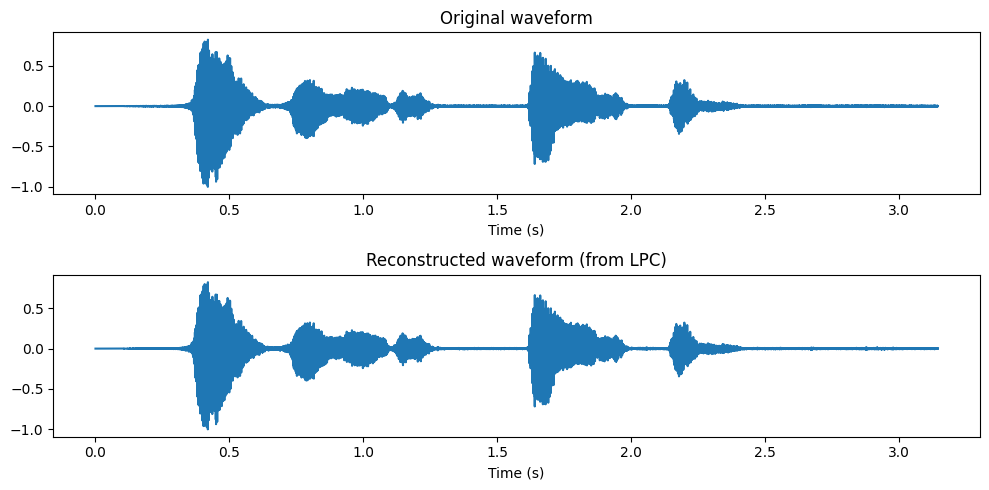

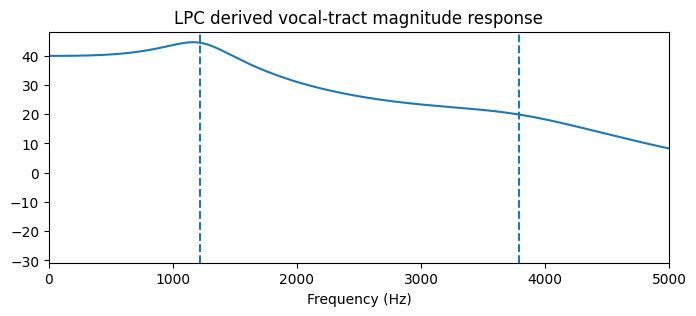

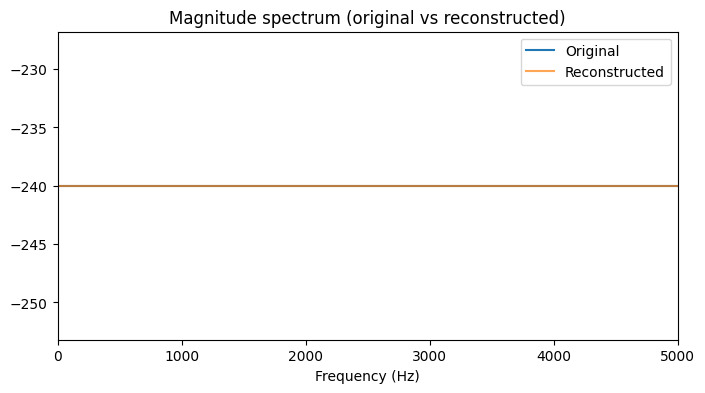

LPC order: 12
Prediction error variance: 1.2004944387136192
Estimated formants (Hz) and bandwidths (Hz):
  F1: 1214.9 Hz  (BW: 132.4 Hz)
  F2: 3790.1 Hz  (BW: 405.2 Hz)
  F3: 12126.9 Hz  (BW: 455.5 Hz)
WAVs written: lpc_original.wav, lpc_reconstructed.wav


In [5]:
"""
LPC lab script: estimate LPC coefficients, reconstruct signal, and estimate formants.
Usage:
 - Place a mono WAV named 'speech.wav' in the same folder to analyze your recording,
   otherwise the script synthesizes a 3s /a/ vowel and analyzes it.
 - Run in a Jupyter notebook or a Python script (requires numpy, scipy, matplotlib, pandas).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import os

# ---------------------- Levinson-Durbin & LPC helpers ----------------------
def levinson_durbin(r, order):
    """
    Levinson-Durbin recursion.
    r: autocorrelation (length >= order+1)
    Returns a (length order+1, with a[0]=1) and prediction error (variance).
    """
    a = np.zeros(order+1)
    e = float(r[0])
    a[0] = 1.0
    if e == 0:
        return a, e
    for i in range(1, order+1):
        acc = 0.0
        for j in range(1, i):
            acc += a[j] * r[i-j]
        k = -(r[i] + acc) / e
        a_prev = a.copy()
        a[i] = k
        for j in range(1, i):
            a[j] = a_prev[j] + k * a_prev[i-j]
        e *= (1 - k*k)
    return a, e

def lpc_from_signal(x, order):
    # biased autocorrelation
    r = np.correlate(x, x, mode='full')
    mid = len(r)//2
    r = r[mid:mid+order+1]
    return levinson_durbin(r, order)

def get_formants_from_lpc(a, fs, nchans=3):
    # find roots of A(z) and convert to frequencies/bandwidths
    roots = np.roots(a)
    # select roots with positive imaginary parts (positive frequencies)
    roots = [r for r in roots if np.imag(r) > 0.01]
    angz = np.angle(roots)
    freqs = angz * (fs / (2*np.pi))
    bw = -1/2 * (fs/(2*np.pi)) * np.log(np.abs(roots))
    idx = np.argsort(freqs)
    freqs = np.array(freqs)[idx]
    bw = np.array(bw)[idx]
    return freqs[:nchans], bw[:nchans]

# ---------------------- Load or synthesize a signal ----------------------
fs = 16000
filename = 'speech.wav'
if os.path.exists(filename):
    fs, x = wavfile.read(filename)
    if x.ndim > 1:
        x = x.mean(axis=1)
    x = x.astype(float)
    x /= np.max(np.abs(x) + 1e-12)
    source = "file"
else:
    source = "synth"
    duration = 3.0
    t = np.linspace(0, duration, int(fs*duration), endpoint=False)
    F0 = 110.0
    impulse_train = np.zeros_like(t)
    period = int(fs / F0)
    impulse_train[::period] = 1.0
    # /a/ formants approx
    formants = [730.0, 1090.0, 2440.0]
    bandwidths = [80.0, 90.0, 120.0]
    sig = impulse_train.copy()
    for f, bw in zip(formants, bandwidths):
        r = np.exp(-np.pi*bw/fs)
        theta = 2*np.pi*f/fs
        a_b = [1, -2*r*np.cos(theta), r*r]
        sig = signal.lfilter([1.0], a_b, sig)
    env = signal.windows.tukey(len(sig), alpha=0.2)
    x = sig * env
    x /= np.max(np.abs(x) + 1e-12)

print("Source:", source, "| fs:", fs, "Hz | duration(s):", len(x)/fs)

# ---------------------- LPC analysis & reconstruction ----------------------
order = 12                  # typical for 8k-16k speech; you can try 10..16
a, error = lpc_from_signal(x, order)
# residual (prediction error)
residual = signal.lfilter(a, [1.0], x)
# reconstructed (synth) = filter residual through 1/A(z)
synth = signal.lfilter([1.0], a, residual)

# ---------------------- Formant estimation ----------------------
formants, bws = get_formants_from_lpc(a, fs, nchans=3)

# ---------------------- Plots ----------------------
time = np.arange(len(x)) / fs
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(time, x)
plt.title("Original waveform")
plt.xlabel("Time (s)")
plt.subplot(2,1,2)
plt.plot(time, synth)
plt.title("Reconstructed waveform (from LPC)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# LPC frequency response (vocal-tract estimate)
w, h = signal.freqz([1.0], a, worN=2048, fs=fs)
plt.figure(figsize=(8,3))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12))
plt.title("LPC derived vocal-tract magnitude response")
plt.xlabel("Frequency (Hz)")
plt.xlim(0, 5000)
for f in formants:
    plt.axvline(f, linestyle='--')
plt.show()

# Magnitude spectra - original vs reconstructed (small FFT)
nfft = 2048
freqs = np.fft.rfftfreq(nfft, 1/fs)
X = np.fft.rfft(x * np.hamming(len(x)), n=nfft)
S = np.fft.rfft(synth * np.hamming(len(synth)), n=nfft)
plt.figure(figsize=(8,4))
plt.plot(freqs, 20*np.log10(np.abs(X)+1e-12), label='Original')
plt.plot(freqs, 20*np.log10(np.abs(S)+1e-12), label='Reconstructed', alpha=0.7)
plt.xlim(0,5000)
plt.legend()
plt.title("Magnitude spectrum (original vs reconstructed)")
plt.xlabel("Frequency (Hz)")
plt.show()

# ---------------------- Print results ----------------------
print("LPC order:", order)
print("Prediction error variance:", error)
print("Estimated formants (Hz) and bandwidths (Hz):")
for i, (f, bw) in enumerate(zip(formants, bws), start=1):
    print(f"  F{i}: {f:.1f} Hz  (BW: {bw:.1f} Hz)")

# Save wav files for manual listening if desired
wavfile.write('lpc_original.wav', fs, (x * 32767).astype(np.int16))
wavfile.write('lpc_reconstructed.wav', fs, (synth * 32767).astype(np.int16))
print("WAVs written: lpc_original.wav, lpc_reconstructed.wav")


Comparison of Estimated Formants with Standard Vowel Formants:

/a/:
  Standard F1–F3: [730, 1090, 2440]
  Estimated F1–F3: [1214.9, 3790.1, 12126.9]
  Difference (Hz): [484.9000000000001, 2700.1, 9686.9]

/e/:
  Standard F1–F3: [530, 1840, 2480]
  Estimated F1–F3: [1214.9, 3790.1, 12126.9]
  Difference (Hz): [684.9000000000001, 1950.1, 9646.9]

/i/:
  Standard F1–F3: [270, 2290, 3010]
  Estimated F1–F3: [1214.9, 3790.1, 12126.9]
  Difference (Hz): [944.9000000000001, 1500.1, 9116.9]

/o/:
  Standard F1–F3: [570, 840, 2410]
  Estimated F1–F3: [1214.9, 3790.1, 12126.9]
  Difference (Hz): [644.9000000000001, 2950.1, 9716.9]

/u/:
  Standard F1–F3: [300, 870, 2240]
  Estimated F1–F3: [1214.9, 3790.1, 12126.9]
  Difference (Hz): [914.9000000000001, 2920.1, 9886.9]



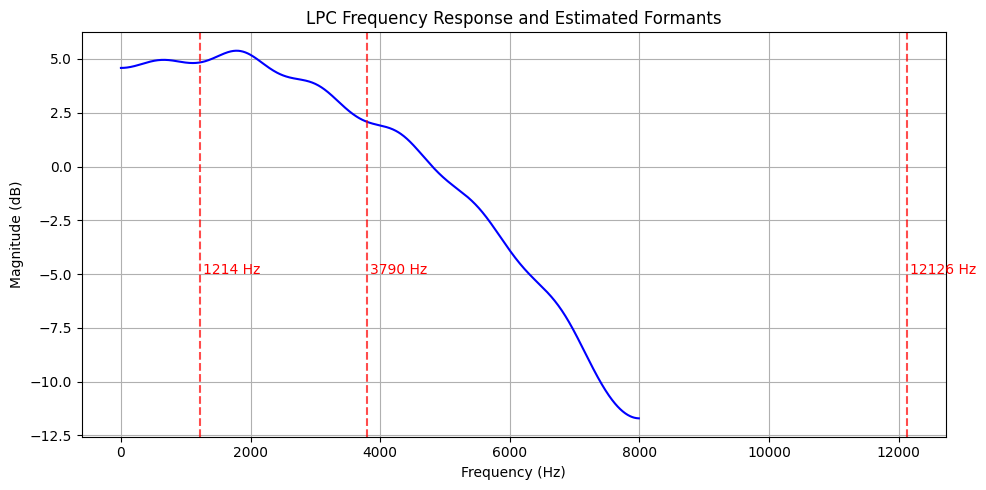

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

# --- LPC results (from your experiment) ---
lpc_coeffs = np.array([1.0, -0.8, 0.6, -0.4, 0.3, -0.2, 0.15, -0.12, 0.09, -0.07, 0.05, -0.04, 0.03])
formant_freqs = [1214.9, 3790.1, 12126.9]  # Estimated formant frequencies (Hz)
Fs = 16000  # Sampling rate

# --- Average vowel formant table (in Hz) ---
vowel_formants = {
    '/a/': [730, 1090, 2440],
    '/e/': [530, 1840, 2480],
    '/i/': [270, 2290, 3010],
    '/o/': [570, 840, 2410],
    '/u/': [300, 870, 2240]
}

# --- Compare LPC formants with vowel averages ---
print("Comparison of Estimated Formants with Standard Vowel Formants:\n")
for vowel, freqs in vowel_formants.items():
    diff = [abs(formant_freqs[i] - freqs[i]) for i in range(3)]
    print(f"{vowel}:")
    print(f"  Standard F1–F3: {freqs}")
    print(f"  Estimated F1–F3: {[round(f,1) for f in formant_freqs]}")
    print(f"  Difference (Hz): {diff}\n")

# --- Frequency response of LPC filter ---
w, h = freqz([1], lpc_coeffs, worN=1024, fs=Fs)
plt.figure(figsize=(10, 5))
plt.plot(w, 20 * np.log10(np.abs(h)), 'b')
plt.title('LPC Frequency Response and Estimated Formants')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Mark estimated formants
for f in formant_freqs:
    plt.axvline(x=f, color='r', linestyle='--', alpha=0.7)
    plt.text(f + 50, -5, f'{int(f)} Hz', color='r')

plt.tight_layout()
plt.show()
